Starting Matrix Grid Training...

COMPARATIVE PERFORMANCE MATRIX
           Epochs to Converge Final Training Loss Final Validation Loss  \
SGD + MSE                 400              0.0584                0.0385   
SGD + BCE                 229              0.1527                0.1409   
Adam + MSE                 97              0.0286                0.0489   
Adam + BCE                 80              0.1224                0.1684   

           Final Test Accuracy  
SGD + MSE               92.11%  
SGD + BCE               94.74%  
Adam + MSE              96.49%  
Adam + BCE              93.86%  


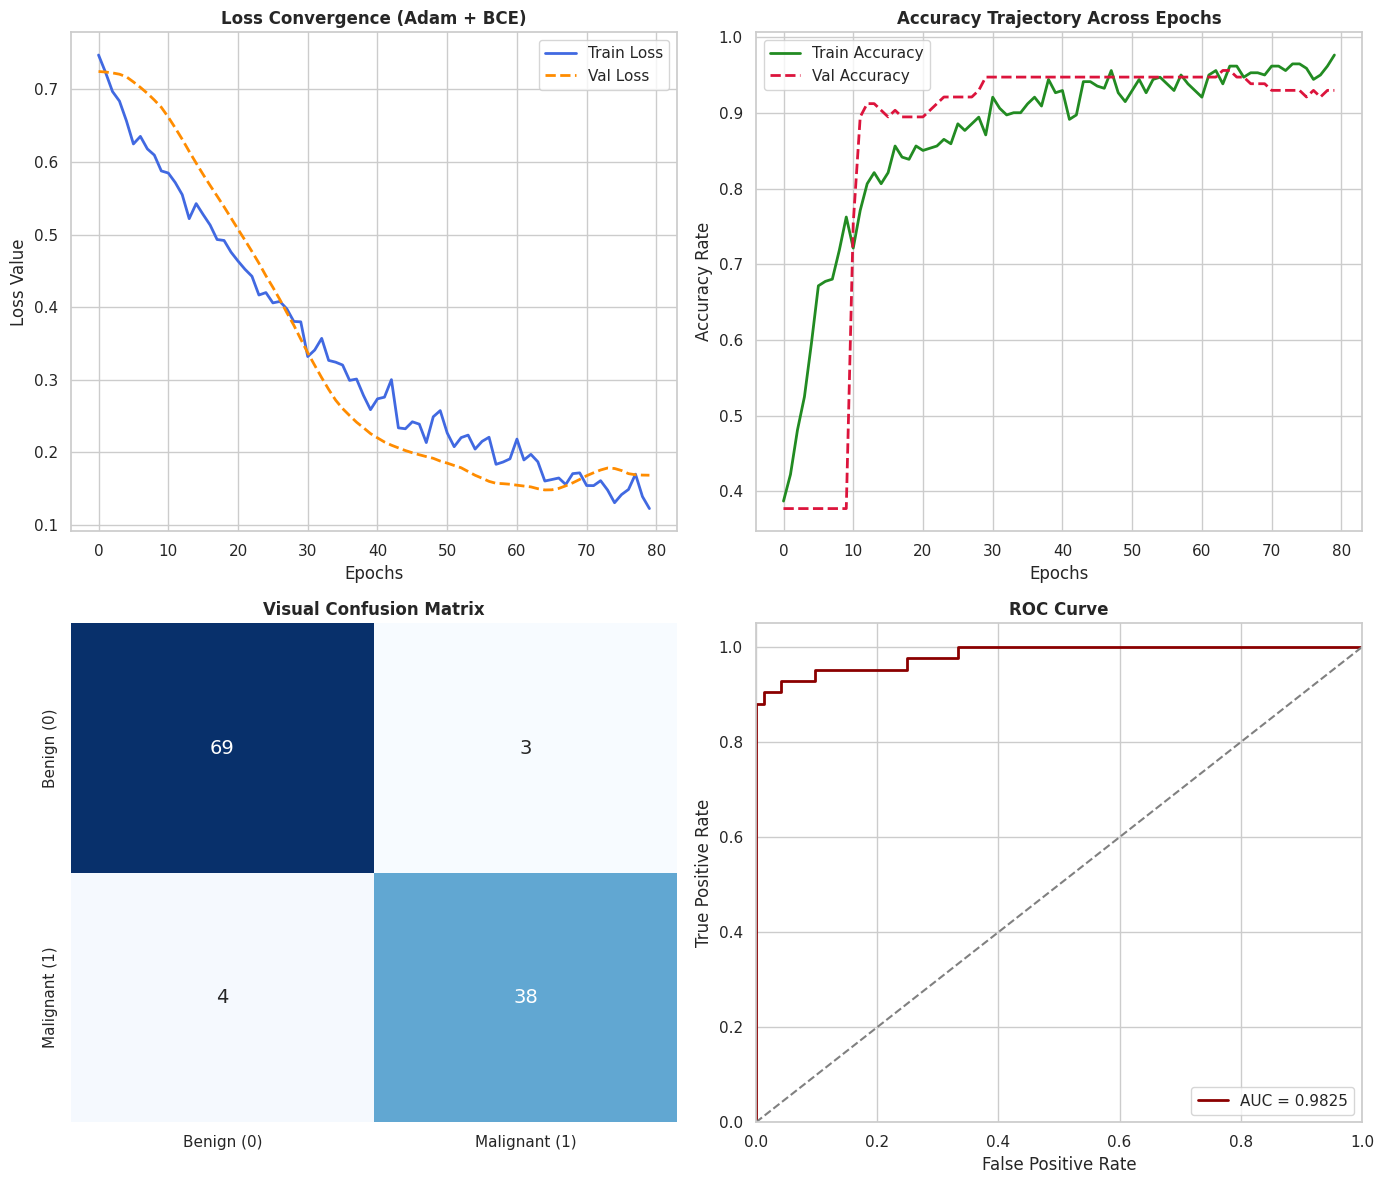


DETAILED CLINICAL METRICS (Best Model)
Precision: 0.9268 | Recall: 0.9048 | Specificity: 0.9583 | F1-Score: 0.9157 | AUC: 0.9825


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc
import urllib.request

sns.set_theme(style="whitegrid")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
data_path = "wdbc.data"

if not os.path.exists(data_path):
    urllib.request.urlretrieve(url, data_path)

columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
df = pd.read_csv(data_path, header=None, names=columns)

df['Target'] = df['Diagnosis'].map({'M': 1, 'B': 0})
X = df[[f'Feature_{i}' for i in range(1, 21)]].values
y = df['Target'].values

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

class CancerClassifierFFNN(nn.Module):
    def __init__(self, use_bn=False, dropout_rate=0.0):
        super(CancerClassifierFFNN, self).__init__()
        layers = []
        input_dim = 20
        hidden_dims = [10, 10, 10, 10, 10]
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            if use_bn:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(p=dropout_rate))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def train_model(model, criterion, optimizer, max_epochs=300, patience=10):
    best_loss = float('inf')
    best_weights = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        train_preds = (outputs >= 0.5).float()
        train_acc = (train_preds == y_train_t).sum().item() / y_train_t.size(0)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t)
            val_preds = (val_outputs >= 0.5).float()
            val_acc = (val_preds == y_val_t).sum().item() / y_val_t.size(0)

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss.item() < best_loss:
            best_loss = val_loss.item()
            best_weights = model.state_dict().copy()
            patience_counter = 0
        else:
            pvariance_counter = patience_counter + 1
            patience_counter += 1

        if patience_counter >= patience:
            model.load_state_dict(best_weights)
            return history, epoch + 1

    if best_weights is not None:
        model.load_state_dict(best_weights)
    return history, max_epochs

experiments = {
    'SGD + MSE': {'opt': 'SGD', 'loss': nn.MSELoss()},
    'SGD + BCE': {'opt': 'SGD', 'loss': nn.BCELoss()},
    'Adam + MSE': {'opt': 'Adam', 'loss': nn.MSELoss()},
    'Adam + BCE': {'opt': 'Adam', 'loss': nn.BCELoss()}
}

results_matrix = {}
histories = {}

print("Starting Matrix Grid Training...")
for name, config in experiments.items():
    model = CancerClassifierFFNN(use_bn=True, dropout_rate=0.2)
    if config['opt'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = config['loss']
    history, converged_epoch = train_model(model, criterion, optimizer, max_epochs=400, patience=15)

    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        test_preds = (test_outputs >= 0.5).float()
        test_acc = (test_preds == y_test_t).sum().item() / y_test_t.size(0)

    results_matrix[name] = {
        'Epochs to Converge': converged_epoch,
        'Final Training Loss': f"{history['train_loss'][-1]:.4f}",
        'Final Validation Loss': f"{history['val_loss'][-1]:.4f}",
        'Final Test Accuracy': f"{test_acc * 100:.2f}%"
    }
    histories[name] = (history, model, test_outputs.numpy())

df_results = pd.DataFrame(results_matrix).T
print("\n" + "="*50 + "\nCOMPARATIVE PERFORMANCE MATRIX\n" + "="*50)
print(df_results)

best_setup = 'Adam + BCE'
best_history, best_model, test_probs = histories[best_setup]
y_test_np = y_test
test_preds_np = (test_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_np, test_preds_np).ravel()

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs[0, 0].plot(best_history['train_loss'], label='Train Loss', color='royalblue', lw=2)
axs[0, 0].plot(best_history['val_loss'], label='Val Loss', color='darkorange', linestyle='--', lw=2)
axs[0, 0].set_title(f'Loss Convergence ({best_setup})', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Loss Value')
axs[0, 0].legend()

axs[0, 1].plot(best_history['train_acc'], label='Train Accuracy', color='forestgreen', lw=2)
axs[0, 1].plot(best_history['val_acc'], label='Val Accuracy', color='crimson', linestyle='--', lw=2)
axs[0, 1].set_title('Accuracy Trajectory Across Epochs', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('Accuracy Rate')
axs[0, 1].legend()

cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[1, 0], cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'], annot_kws={"size": 14})
axs[1, 0].set_title('Visual Confusion Matrix', fontsize=12, fontweight='bold')

fpr, tpr_thresholds, _ = roc_curve(y_test_np, test_probs)
roc_auc = auc(fpr, tpr_thresholds)
axs[1, 1].plot(fpr, tpr_thresholds, color='darkred', lw=2, label=f'AUC = {roc_auc:.4f}')
axs[1, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axs[1, 1].set_xlim([0.0, 1.0])
axs[1, 1].set_ylim([0.0, 1.05])
axs[1, 1].set_xlabel('False Positive Rate')
axs[1, 1].set_ylabel('True Positive Rate')
axs[1, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axs[1, 1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('clinical_diagnostic_dashboard.png', dpi=300)
plt.show()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "="*50 + "\nDETAILED CLINICAL METRICS (Best Model)\n" + "="*50)
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | Specificity: {specificity:.4f} | F1-Score: {f1_score:.4f} | AUC: {roc_auc:.4f}")
print("="*50)